<a href="https://colab.research.google.com/github/afthalla2929/MScBA-Files/blob/Project_and_Case_Studies/Loan_Approval_Classification_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Classification Using Random Forest

**MBN 603 Programming for Data Analytics**  
Theme 1: Predictive Modeling (Supervised Learning)  

This notebook is fully reproducible and follows the required analytics workflow: data acquisition, cleaning, preprocessing, feature engineering, core model implementation, advanced model implementation, evaluation, and business interpretation.

## 1. Import libraries
The project uses Python with NumPy, Pandas, and scikit-learn as required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
DATA_PATH = "/content/Dataset _ Ali _ Fatema_ Nahla.csv"
pd.set_option("display.max_columns", None)

## 2. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum().to_frame("missing_count"))

Dataset shape: (32581, 12)


,Age,Annual Income,Home ownership,Employment length (in years),Loan intent,Loan grade,Loan amount,Interest rate,Loan status (0 is non default 1 is default),loan_percent_income,Historical default,Credit history length
0,22,"59,000",RENT,12.0,PERSONAL,D,"35,000",16.02,1,0.59,Y,3
1,21,"9,600",OWN,5.0,EDUCATION,B,"1,000",11.14,0,0.10,N,2
2,25,"9,600",MORTGAGE,1.0,MEDICAL,C,"5,500",12.87,1,0.57,N,3
3,23,"65,500",RENT,4.0,MEDICAL,C,"35,000",15.23,1,0.53,N,2
4,24,"54,400",RENT,8.0,MEDICAL,C,"35,000",14.27,1,0.55,Y,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age                                          32581 non-null  int64  
 1   Annual Income                                32581 non-null  object 
 2   Home ownership                               32581 non-null  object 
 3   Employment length (in years)                 31686 non-null  float64
 4   Loan intent                                  32581 non-null  object 
 5   Loan grade                                   32581 non-null  object 
 6   Loan amount                                  32581 non-null  object 
 7   Interest rate                                29465 non-null  float64
 8   Loan status (0 is non default 1 is default)  32581 non-null  int64  
 9   loan_percent_income                          32581 non-null  float64
 10

None

,missing_count
Age,0
Annual Income,0
Home ownership,0
Employment length (in years),895
Loan intent,0
Loan grade,0
Loan amount,0
Interest rate,3116
Loan status (0 is non default 1 is default),0
loan_percent_income,0


## 3. Data cleaning
The dataset stores `Annual Income` and `Loan amount` with comma separators, so they are cleaned into numeric columns. Missing values are not removed; they are handled inside the modeling pipeline to avoid data leakage.

In [3]:
df_clean = df.copy()

for col in ["Annual Income", "Loan amount"]:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

target = "Loan status (0 is non default 1 is default)"

print(df_clean.dtypes)
print("\nClass distribution:")
display(df_clean[target].value_counts(normalize=False).rename("count").to_frame())
display(df_clean[target].value_counts(normalize=True).rename("proportion").to_frame())

Age                                              int64
Annual Income                                  float64
Home ownership                                  object
Employment length (in years)                   float64
Loan intent                                     object
Loan grade                                      object
Loan amount                                    float64
Interest rate                                  float64
Loan status (0 is non default 1 is default)      int64
loan_percent_income                            float64
Historical default                              object
Credit history length                            int64
dtype: object

Class distribution:


,count
Loan status (0 is non default 1 is default),
0,25473
1,7108


,proportion
Loan status (0 is non default 1 is default),
0,0.781836
1,0.218164


## 4. Exploratory visualization

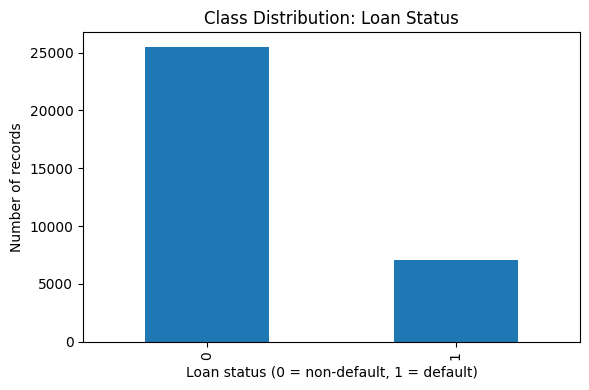

In [4]:
ax = df_clean[target].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
ax.set_title("Class Distribution: Loan Status")
ax.set_xlabel("Loan status (0 = non-default, 1 = default)")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

## 5. Feature engineering
The engineered variables are designed to be business interpretable: affordability, repayment pressure, credit maturity, employment stability, and interaction between cost of credit and loan burden.

In [5]:
df_model = df_clean.copy()

df_model["loan_to_income_engineered"] = df_model["Loan amount"] / df_model["Annual Income"].replace(0, np.nan)
df_model["monthly_income"] = df_model["Annual Income"] / 12
df_model["monthly_payment_pressure_proxy"] = (
    df_model["Loan amount"] * (df_model["Interest rate"].fillna(df_model["Interest rate"].median()) / 100)
) / df_model["Annual Income"].replace(0, np.nan)
df_model["employment_to_age_ratio"] = df_model["Employment length (in years)"] / df_model["Age"].replace(0, np.nan)
df_model["credit_history_to_age_ratio"] = df_model["Credit history length"] / df_model["Age"].replace(0, np.nan)
df_model["interest_x_loan_percent_income"] = df_model["Interest rate"] * df_model["loan_percent_income"]
df_model["high_interest_flag"] = (df_model["Interest rate"] >= df_model["Interest rate"].quantile(0.75)).astype(int)

df_model = df_model.replace([np.inf, -np.inf], np.nan)

engineered_features = [
    "loan_to_income_engineered", "monthly_income", "monthly_payment_pressure_proxy",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "interest_x_loan_percent_income", "high_interest_flag"
]

display(df_model[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
loan_to_income_engineered,32581.0,0.170553,0.107049,0.000789,0.089655,0.148148,0.229167,0.830000
monthly_income,32581.0,5506.237372,5165.259931,333.333333,3208.333333,4583.333333,6600.000000,500000.000000
monthly_payment_pressure_proxy,32581.0,0.019170,0.014078,0.000087,0.008738,0.015491,0.026050,0.114937
employment_to_age_ratio,31686.0,0.174237,0.138980,0.000000,0.064516,0.142857,0.272727,5.857143
credit_history_to_age_ratio,32581.0,0.194744,0.093543,0.013889,0.125000,0.173913,0.260000,0.588235
interest_x_loan_percent_income,29465.0,1.914867,1.422274,0.000000,0.860600,1.532000,2.606100,11.585700
high_interest_flag,32581.0,0.229029,0.420215,0.000000,0.000000,0.000000,0.000000,1.000000


## 6. Train-test split and preprocessing pipelines
The preprocessing is placed inside scikit-learn pipelines. This is important because imputers, scalers, and encoders must learn only from the training data.

In [6]:
X = df_model.drop(columns=[target])
y = df_model[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Numerical features: ['Age', 'Annual Income', 'Employment length (in years)', 'Loan amount', 'Interest rate', 'loan_percent_income', 'Credit history length', 'loan_to_income_engineered', 'monthly_income', 'monthly_payment_pressure_proxy', 'employment_to_age_ratio', 'credit_history_to_age_ratio', 'interest_x_loan_percent_income', 'high_interest_flag']
Categorical features: ['Home ownership', 'Loan intent', 'Loan grade', 'Historical default']
Train shape: (26064, 18) Test shape: (6517, 18)


## 7. Model implementation
Two core models are included to satisfy the technical requirement: Logistic Regression and Decision Tree. Random Forest is the advanced model.

In [7]:
models = {
    "Logistic Regression (core baseline)": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
    ]),
    "Decision Tree (core interpretable)": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=50, class_weight="balanced", random_state=RANDOM_STATE
        ))
    ]),
    "Random Forest (advanced final)": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

## 8. Evaluation function
Classification performance is evaluated with accuracy, balanced accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrix.

In [8]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }
    return metrics, y_pred, y_prob

all_metrics = []
predictions = {}

for name, model in models.items():
    metrics, y_pred, y_prob = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    all_metrics.append(metrics)
    predictions[name] = {"prediction": y_pred, "probability": y_prob}

results = pd.DataFrame([
    {k: v for k, v in m.items() if k != "Confusion Matrix"} for m in all_metrics
])

display(results.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression (core baseline),0.8188,0.8088,0.5600,0.7911,0.6558,0.8802,0.7455
1,Decision Tree (core interpretable),0.8990,0.8429,0.7830,0.7433,0.7626,0.9040,0.8376
2,Random Forest (advanced final),0.9306,0.8537,0.9533,0.7173,0.8186,0.9319,0.8852


## 9. Confusion matrices and classification reports

In [9]:
for metrics in all_metrics:
    print("\n" + "=" * 90)
    print(metrics["Model"])
    print("Confusion matrix:\n", metrics["Confusion Matrix"])
    print(classification_report(
        y_test,
        predictions[metrics["Model"]]["prediction"],
        target_names=["Non-default", "Default"]
    ))


Logistic Regression (core baseline)
Confusion matrix:
 [[4211  884]
 [ 297 1125]]
              precision    recall  f1-score   support

 Non-default       0.93      0.83      0.88      5095
     Default       0.56      0.79      0.66      1422

    accuracy                           0.82      6517
   macro avg       0.75      0.81      0.77      6517
weighted avg       0.85      0.82      0.83      6517


Decision Tree (core interpretable)
Confusion matrix:
 [[4802  293]
 [ 365 1057]]
              precision    recall  f1-score   support

 Non-default       0.93      0.94      0.94      5095
     Default       0.78      0.74      0.76      1422

    accuracy                           0.90      6517
   macro avg       0.86      0.84      0.85      6517
weighted avg       0.90      0.90      0.90      6517


Random Forest (advanced final)
Confusion matrix:
 [[5045   50]
 [ 402 1020]]
              precision    recall  f1-score   support

 Non-default       0.93      0.99      0.96     

## 10. Model comparison visualization

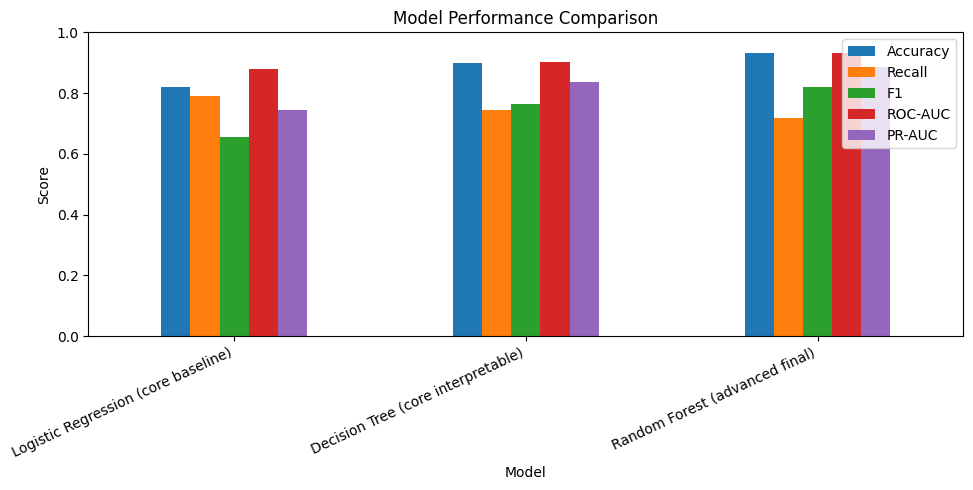

In [10]:
comparison = results.set_index("Model")[["Accuracy", "Recall", "F1", "ROC-AUC", "PR-AUC"]]
ax = comparison.plot(kind="bar", figsize=(10, 5))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 11. Random Forest threshold analysis
The default threshold of 0.50 is not always the best business threshold. A lower threshold increases default detection but creates more manual-review cases.

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1
29,0.39,0.9234,0.8633,0.8755,0.7567,0.8118
17,0.27,0.8944,0.8633,0.7347,0.8080,0.7696
21,0.31,0.9067,0.8633,0.7862,0.7862,0.7862
27,0.37,0.9213,0.8632,0.8627,0.7602,0.8082
28,0.38,0.9221,0.8632,0.8674,0.7588,0.8095
19,0.29,0.9006,0.8629,0.7597,0.7961,0.7775
18,0.28,0.8969,0.8626,0.7451,0.8017,0.7724
25,0.35,0.9167,0.8626,0.8378,0.7665,0.8006
30,0.40,0.9242,0.8625,0.8822,0.7532,0.8126
24,0.34,0.9142,0.8625,0.8247,0.7707,0.7968


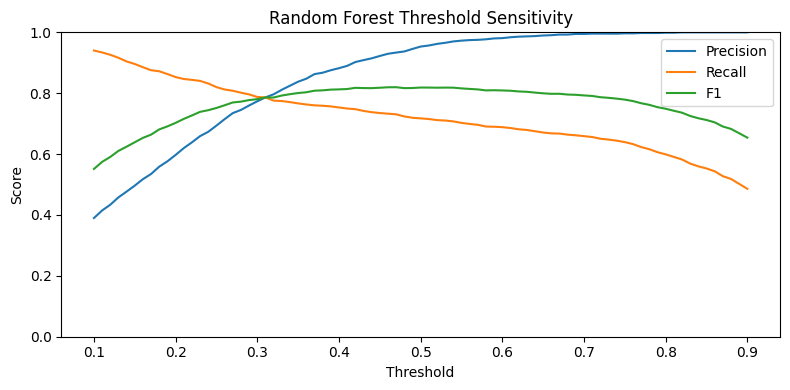

In [11]:
rf_prob = predictions["Random Forest (advanced final)"]["probability"]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    threshold_pred = (rf_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, threshold_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, threshold_pred),
        "Precision": precision_score(y_test, threshold_pred, zero_division=0),
        "Recall": recall_score(y_test, threshold_pred),
        "F1": f1_score(y_test, threshold_pred)
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.sort_values("Balanced Accuracy", ascending=False).head(10).round(4))

ax = threshold_results.plot(x="Threshold", y=["Precision", "Recall", "F1"], figsize=(8, 4))
ax.set_title("Random Forest Threshold Sensitivity")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 12. Random Forest feature importance

,Feature,Importance,Feature clean
9,num__monthly_payment_pressure_proxy,0.101691,monthly_payment_pressure_proxy
7,num__loan_to_income_engineered,0.101111,loan_to_income_engineered
4,num__Interest rate,0.085129,Interest rate
8,num__monthly_income,0.075242,monthly_income
1,num__Annual Income,0.074314,Annual Income
12,num__interest_x_loan_percent_income,0.068995,interest_x_loan_percent_income
5,num__loan_percent_income,0.067984,loan_percent_income
27,cat__Loan grade_D,0.041412,Loan grade_D
3,num__Loan amount,0.037385,Loan amount
17,cat__Home ownership_RENT,0.035469,Home ownership_RENT


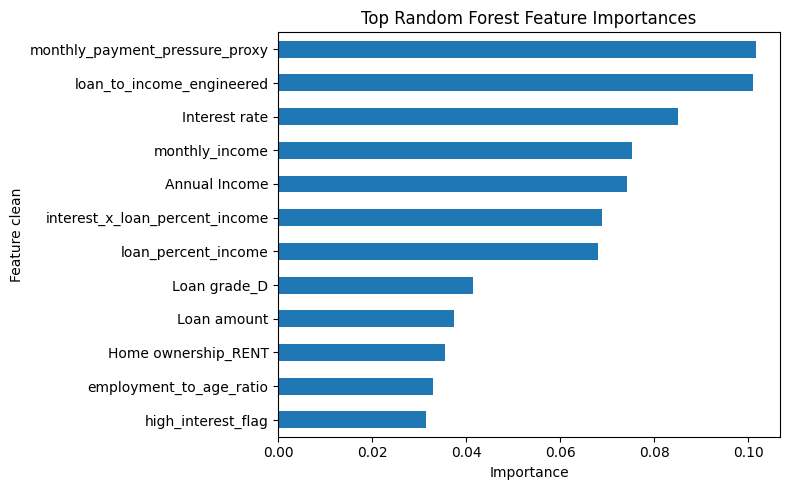

In [12]:
rf_model = models["Random Forest (advanced final)"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
)

feature_importance["Feature clean"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(feature_importance.head(15))

top_features = feature_importance.head(12).iloc[::-1]
ax = top_features.plot(kind="barh", x="Feature clean", y="Importance", legend=False, figsize=(8, 5))
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 13. Business interpretation

The advanced Random Forest model is recommended because it achieved the strongest overall performance:

- Accuracy: **0.930**
- F1-score for default class: **0.818**
- ROC-AUC: **0.932**
- PR-AUC: **0.885**

The model should be used as a decision-support tool, not as an automatic rejection system. A practical implementation should create three risk bands:

1. **Low risk:** fast-track standard approval.
2. **Medium risk:** manual underwriting review.
3. **High risk:** enhanced affordability checks, risk-adjusted pricing, lower loan amount, collateral, or rejection.

The most important predictors are related to repayment affordability, loan burden, interest rate, income capacity, and borrower history. These findings are consistent with credit risk logic and are useful for managerial decision-making.